# Customer Churn Prediction
### For Telecommunication Service Provider

## Objective
**To apply a feedforward neural network to predict customer churn and to identify the key behavioural and service-related factors that influence customer retention.**

In [1]:
# Importing basic necesaary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
# installing tenserflow for neural networks
!pip install tensorflow

In [3]:
# importing tenserflow libraries for neural network model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Data Understanding and Preparation

### Loading & Reading Dataset

In [24]:
# Loading dataset from the file provided
df = pd.read_csv("D:/BITS DS & AI/Artificial Neural Networks/telco_churn.csv")

In [25]:
# reading dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


The dataset has 7043 records and 21 variables

In [27]:
# information about dataset records, index, variables, data types and storage memory
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Data Dictionary:**    

- customerID - Unique identifier for each customer Categorical (ID) Not useful for modeling    
- gender - Customer gender Categorical Male / Female     
- SeniorCitizen - Indicates if customer is a senior citizen Binary (0/1) 1 = Senior Citizen     
- Partner- Whether customer has a partner Categorical Yes / No      
- Dependents- Whether customer has dependents Categorical Yes / No     
- tenure- Number of months customer stayed Numerical Higher implies loyalty     
- PhoneService -Whether customer has phone service Categorical Yes / No     
- MultipleLines- Multiple phone lines Categorical Yes / No / No phone service     
- InternetService- Type of internet service Categorical DSL / Fiber / None     
- OnlineSecurity- Online security service Categorical Yes / No / No internet service     
- OnlineBackup- Online backup service Categorical Yes / No / No internet service     
- DeviceProtection- Device protection service Categorical Yes / No / No internet service     
- TechSupport- Technical support service Categorical Yes / No / No internet service     
- StreamingTV- Streaming TV service Categorical Yes / No / No internet service     
- StreamingMovies- Streaming movies service Categorical Yes / No / No internet service     
- Contract- Contract duration Categorical Month-to-month / One year / Two year     
- PaperlessBilling-  Paperless billing usage Categorical Yes / No PaymentMethod     
- Payment method - Categorical Electronic / Mailed / Bank / Credit     
- MonthlyCharges - Monthly charges Numerical Continuous     
- TotalCharges -  Total charges over tenure Numerical May contain missing values     
- Churn - Customer churn indicator Target (Binary) Yes = Churned    

In [28]:
# finding if there are any null enteries
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**No null enteries found**

In [29]:
# finding if there are any duplicate records
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


**no duplicate records found**

In [30]:
# distinct values in each variable
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### Feature Engineering

In [31]:
# Total charges variables is stored as categorical instead of numeric
# Changing its data type to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [32]:
# dropping customerID bcause its only an identifier, has no significance for the analysis
df = df.drop(['customerID'], axis=1)

In [33]:
# Mapping Target Variable to binary format
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

##### **Explicitly defining categorical columns and numeric columns for effecient pre-processing, EDA and cleaner pipleine**

In [34]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['number']).columns

print(cat_cols)
print(num_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


In [35]:
df[cat_cols].describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


In [36]:
df[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


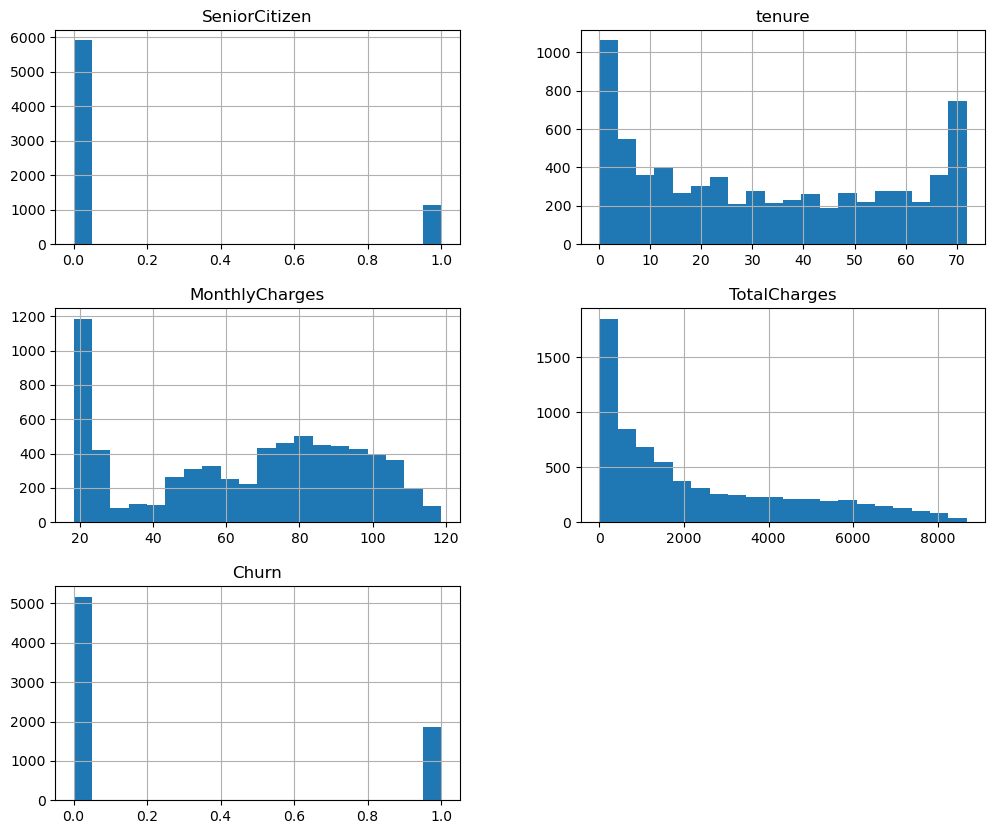

In [37]:
# Distribution of numbered columns in the dataset
df[num_cols].hist(figsize=(12,10), bins=20)
plt.show()

TotalCharges is right skewed 

In [38]:
# Log transform to reduce right skewness
df['TotalCharges'] = np.log1p(df['TotalCharges'])

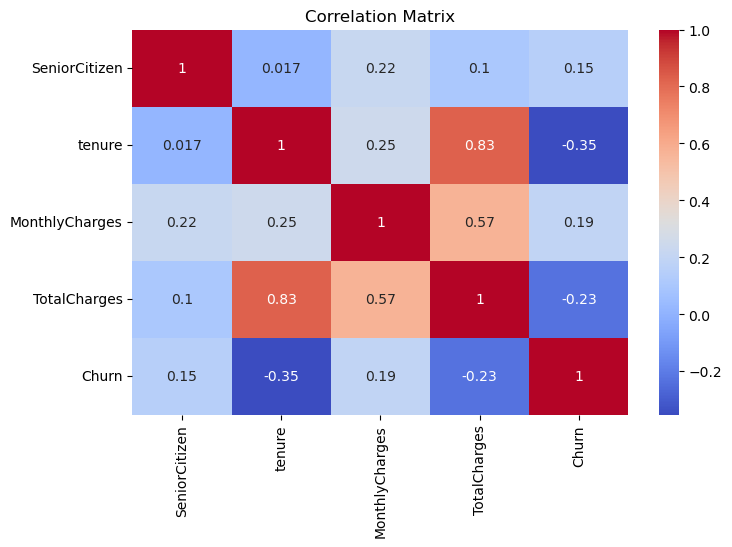

In [39]:
# Correlation Analysis
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix revealed a strong positive correlation (0.83) between tenure and total charges, indicating multicollinearity.       
Since total charges is a cumulative measure derived from tenure and monthly charges, it does not provide independent predictive value.     
Therefore, the original TotalCharges feature was removed.

In [40]:
df = df.drop('TotalCharges', axis=1)

## Exploratory Data Analysis (EDA)

Percentage of Customer Churn:
 Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


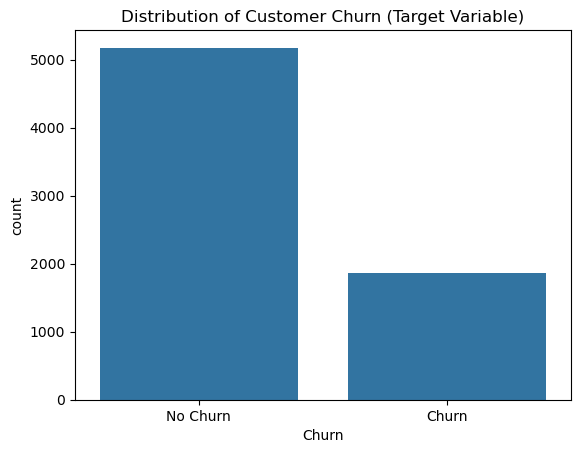

In [42]:
# Visualizing the target variable
counts = df['Churn'].value_counts()
percent = df['Churn'].value_counts(normalize=True) * 100
print("Percentage of Customer Churn:\n", percent)

sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn (Target Variable)')
plt.xticks([0,1], ['No Churn', 'Churn'])
plt.show()

There are 26 % of customers who have left this telecom service provider

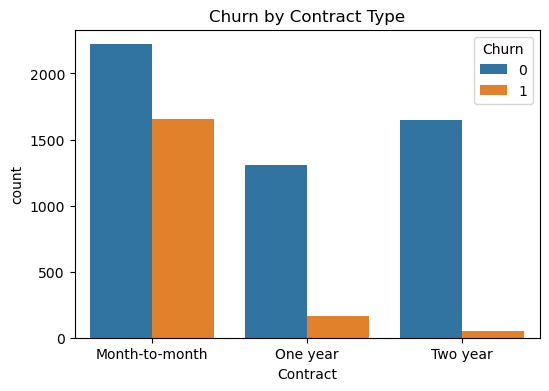

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

Customer Churn is seen more for contract duration that is on month-to-month basis, while its very less for those customers who subscribed for a year and two years.     

This shows that long term contract customers are more happy with the telecom services than monthly contract customers

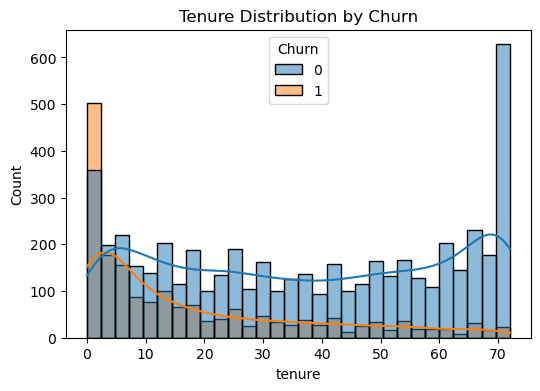

In [44]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

The more the customers stay with the telecom service provider the more happy they are and are less likely to churn.    

While when a customer stays for less than 15 months (1.25 yrs) they are probably monthly contract customers and are more likely to churn

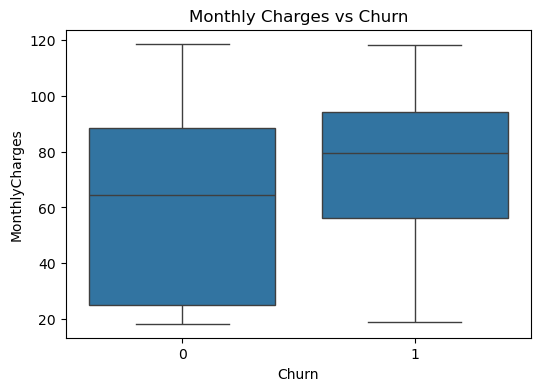

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Monthly charges for those churned were around 80 Rupees, most likely because they were paying month-to-month basis, while long tenured customers are rewarded by company and were charged around 65 Rupees; anywhere between 25 Rupees - 90 Rupees for the type and no. of services they took.  

This shows that customers if commit to long term contract get rewarded with less charges/discounts per month, while those who don't are charged higher and become customers who will most likely churn.

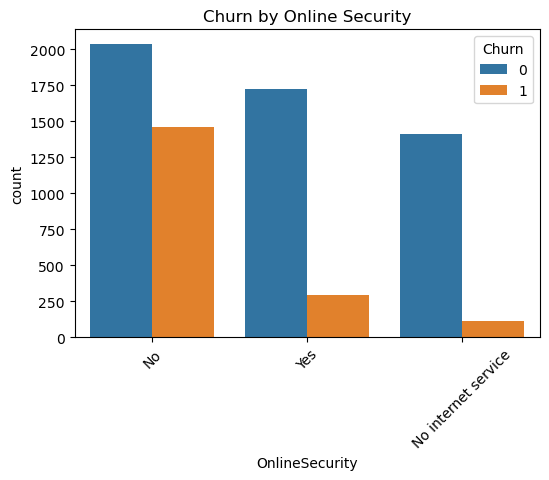

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Online Security")
plt.show()

For those customers who didn't subscribe to the online security service, had a higher churn rate.

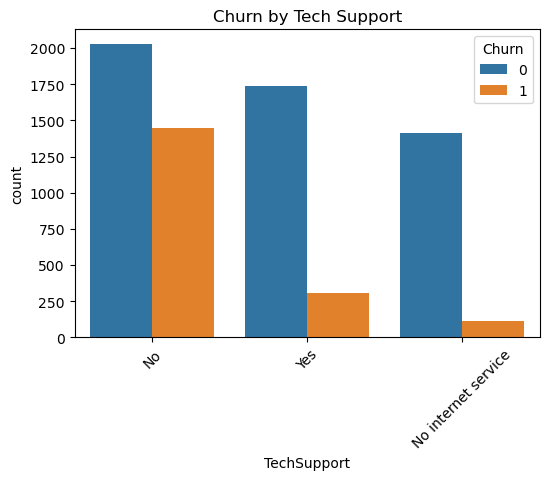

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Tech Support")
plt.show()

Similarly, as online security service, if the customers didn't sign up for tech support service, were ones who churned

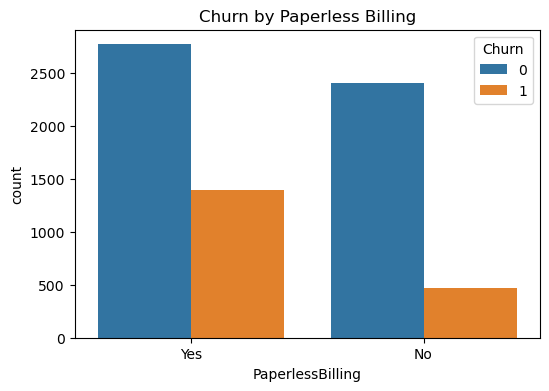

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title("Churn by Paperless Billing")
plt.show()

Paperless Billing or E-Bills -- those customers who did sign up for this, had a higher rate of churn.    

While those who took paper bills - most likely non-tech-savy people or elderly had a lower rate of churn.

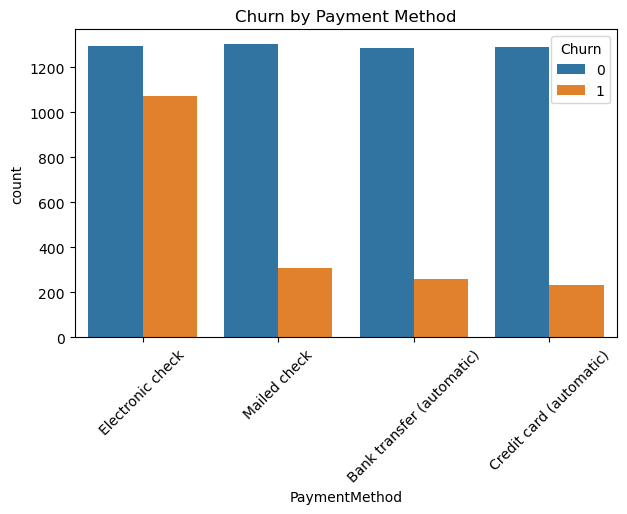

In [49]:
plt.figure(figsize=(7,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

High Customer Churn is seen for electronic check payment method - reflects weaker customer engagement, higher friction in payment processes, or lack of long-term commitment compared to automated payment methods.    
Comparatively mailed check payment has less customer churn due higher success of physical checks being cleared easily.   

This highlights the importance of promoting seamless and recurring payment options to improve retention.

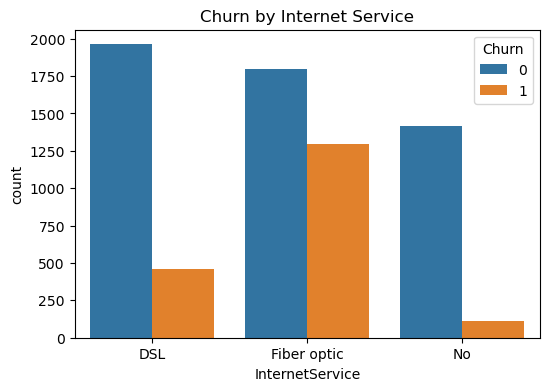

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

Customers with fiber optic internet service has a very high churn rate, could be due to higher expectations regarding service quality or pricing, and any dissatisfaction leads to increased churn.     
In contrast, DSL users exhibit moderate churn, while customers without internet service have minimal churn.    
High value customers' services with the package needs to be looked at for greater customer retention.

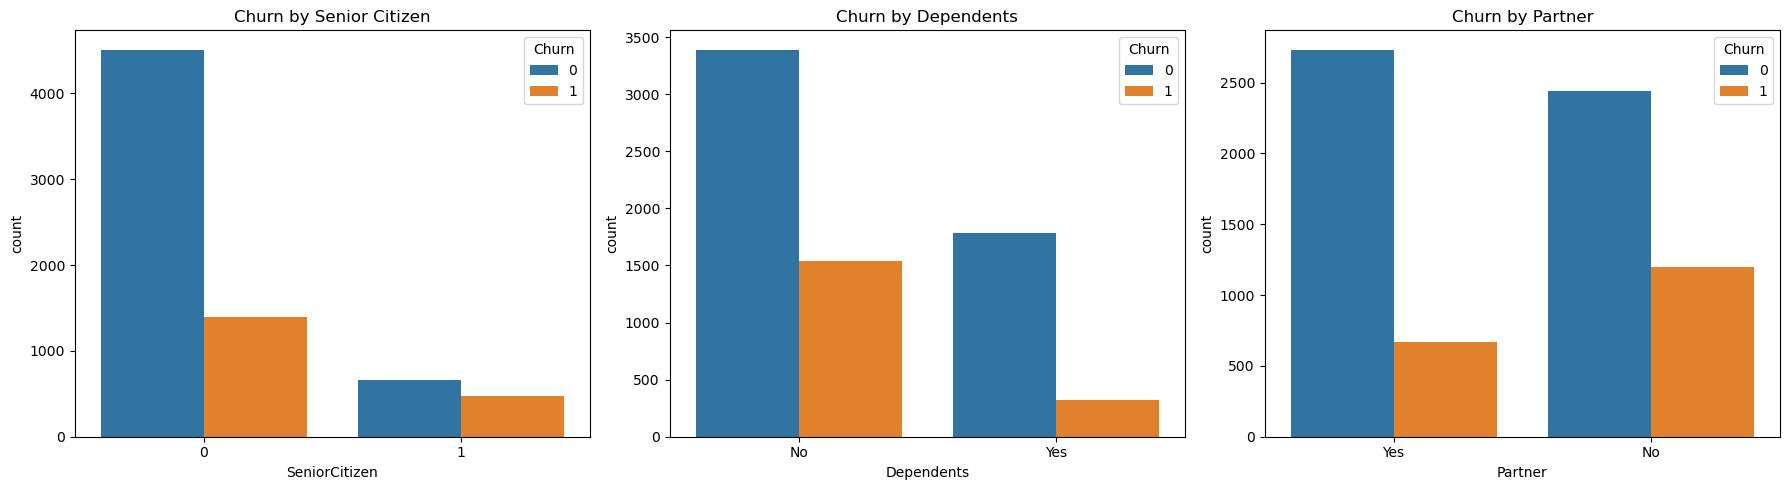

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[0])
axes[0].set_title("Churn by Senior Citizen")

# Dependents
sns.countplot(x='Dependents', hue='Churn', data=df, ax=axes[1])
axes[1].set_title("Churn by Dependents")

# Partner
sns.countplot(x='Partner', hue='Churn', data=df, ax=axes[2])
axes[2].set_title("Churn by Partner")

plt.tight_layout()
plt.show()

Customers with dependents and partners exhibit lower churn rates, suggesting stronger household-level commitment and higher switching costs.      
In contrast, customers without dependents or partners show higher churn, indicating greater flexibility to switch providers and lower attachment to bundled or shared services.        
The effect of senior citizen status is present but less pronounced, indicating demographic factors play a secondary role compared to household composition. 


### One-Hot Encoding 

In [52]:
df1 = pd.get_dummies(df, drop_first=True)

In [53]:
df1.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

### Splitting into Train/Test Dataset

In [54]:
X = df1.drop('Churn', axis=1)
y = df1['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [56]:
# Scaling numerical variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
# Using Randome FOrest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Finding Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances)

                                  Feature  Importance
1                                  tenure    0.244313
2                          MonthlyCharges    0.228766
9             InternetService_Fiber optic    0.046118
27         PaymentMethod_Electronic check    0.038810
24                      Contract_Two year    0.037882
3                             gender_Male    0.033819
18                        TechSupport_Yes    0.029063
23                      Contract_One year    0.028737
25                   PaperlessBilling_Yes    0.028292
4                             Partner_Yes    0.027656
12                     OnlineSecurity_Yes    0.027316
14                       OnlineBackup_Yes    0.025626
0                           SeniorCitizen    0.023304
8                       MultipleLines_Yes    0.023255
5                          Dependents_Yes    0.022355
16                   DeviceProtection_Yes    0.022131
22                    StreamingMovies_Yes    0.020827
20                        St

**Most Important feature influencing customer churn :**     
- tenure: the longer the no. of months a customer stayed the more they become loyal customers
- monthly charges- if they contract longer and take some bundled service package they are are charged at discounted rate which increases customer loyalty
- internet service fiber optic is a very important service- high value customers- if they services and price are lucrative -> higher retention
- electronic check payment method either needs to be made seamless or changed to some other method for high retention

## Neural Network Modelling

In [63]:
model = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
   metrics=['accuracy', 'Precision', 'Recall']
)

model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Precision: 0.6887 - Recall: 0.0985 - accuracy: 0.7512 - loss: 0.5356         
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6447 - Recall: 0.3954 - accuracy: 0.7836 - loss: 0.4558 
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6312 - Recall: 0.4966 - accuracy: 0.7913 - loss: 0.4381 
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6465 - Recall: 0.5108 - accuracy: 0.7978 - loss: 0.4283 
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6360 - Recall: 0.5412 - accuracy: 0.7978 - loss: 0.4241 
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6474 - Recall: 0.5439 - accuracy: 0.8021 - loss: 0.4205 
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6597 - Recall: 0.5310 - accuracy: 0.8046 - loss: 0.4180 
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6636 - Recall: 0.5391 - accuracy: 0.8069 - loss: 0.4166 


The model shows steady improvement in accuracy and loss over epochs, indicating effective learning. However, recall for churn customers remains moderate, suggesting that the model fails to identify a significant portion of customers who are likely to churn.

In [64]:
model.fit(X_train, y_train, 
          epochs=20, 
          batch_size=32,
          class_weight={0:1, 1:2})

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5842 - Recall: 0.6741 - accuracy: 0.7881 - loss: 0.5970 
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5801 - Recall: 0.7011 - accuracy: 0.7879 - loss: 0.5886 
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5789 - Recall: 0.7031 - accuracy: 0.7874 - loss: 0.5865 
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5798 - Recall: 0.7105 - accuracy: 0.7884 - loss: 0.5849 
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5783 - Recall: 0.7126 - accuracy: 0.7877 - loss: 0.5837 
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5846 - Recall: 0.7132 - accuracy: 0.7913 - loss: 0.5829 
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5805 - Recall: 0.7126 - accuracy: 0.7890 - loss: 0.5811 
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5815 - Recall: 0.7152 - accuracy: 0.7897 - loss: 0.5805 
Epoch 9/

The use of class weights significantly improves the model’s ability to detect churn customers, which is critical for business applications. Although precision decreases slightly, this trade-off is acceptable as the cost of missing a churn customer is higher than incorrectly targeting a non-churn customer.

In [65]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
              precision    recall  f1-score   support

           0       0.89      0.80      0.85      1022
           1       0.59      0.75      0.66       387

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.79      0.80      1409

[[821 201]
 [ 97 290]]


The model misses 97 churn customers, which represents a significant business risk as these customers are not targeted for retention strategies.    
This shows strong performance in identifying loyal customers but is less effective at detecting churn customers. This highlights a trade-off between overall accuracy and recall for the minority class.

In [66]:
y_pred_tuned = (model.predict(X_test) > 0.3).astype(int)

print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.94      0.62      0.74      1022
           1       0.47      0.89      0.61       387

    accuracy                           0.69      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.69      0.71      1409

[[629 393]
 [ 43 344]]


The model improves recall for churn customers significantly but at the cost of increased false positives.     
By lowering the threshold, the model identifies more at-risk customers, reducing the number of missed churn cases. Although this increases false positives, it is acceptable in a business context where the cost of missing a churn customer is higher than targeting a non-churn customer.

Two approaches were evaluated after applying class weighting: a standard threshold (0.5) and a lower threshold (0.3). Lowering the threshold significantly increased recall for churn customers (from 75% to 89%), reducing the number of missed churn cases. However, this came at the cost of a substantial decrease in precision and overall accuracy.    
The model with threshold 0.5 was selected as the final model, as it provides a better balance between precision and recall while maintaining higher overall accuracy. This ensures effective identification of churn customers without excessively increasing false positives.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


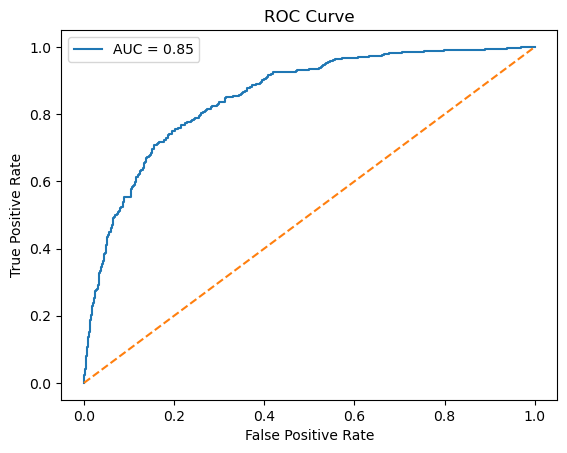

In [67]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve shows how well the model distinguishes between churn and non-churn customers across different thresholds.     

The model achieves an AUC score of 0.85, indicating strong discriminatory power between churn and non-churn customers. This suggests that the model is effective in ranking customers based on their likelihood to churn.

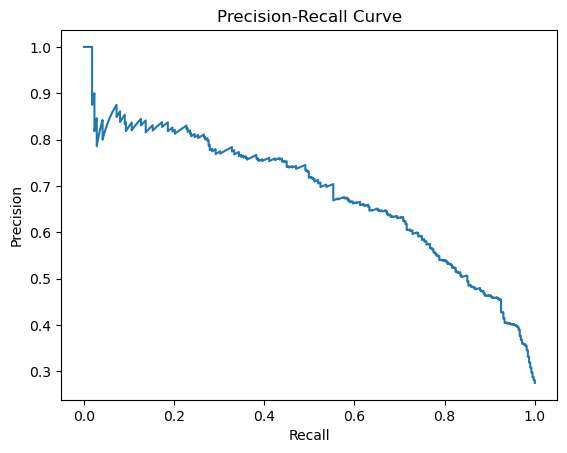

In [68]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

As recall increases → precision decreases    
The precision-recall curve highlights the trade-off between identifying churn customers and avoiding false positives. As recall increases, precision decreases, indicating that capturing more churn customers comes at the cost of misclassifying some non-churn customers.

## Summary

The input features were selected based on correlation analysis and domain relevance.     
Features such as tenure and MonthlyCharges were retained as they showed meaningful relationships with the target variable (churn) and represent customer behavior and pricing sensitivity. The feature TotalCharges was removed due to high multicollinearity with tenure (correlation ≈ 0.83).    
This selection ensures that the model uses informative, non-redundant, and scaled features, which improves learning efficiency and generalization in neural networks.

Loss Function (Binary Crossentropy)      
The loss function used is binary crossentropy, which is appropriate for binary classification problems such as churn prediction (Yes/No). It measures the difference between the predicted probabilities and actual class labels. Since the output layer uses a sigmoid activation function, binary crossentropy is the most suitable choice as it penalizes incorrect predictions more effectively and helps the model converge faster.

Evaluation Metrics     
The primary evaluation metric used is accuracy, which measures the proportion of correctly classified instances. However, since churn datasets are often imbalanced, accuracy alone may not fully capture model performance.       
Therefore, additional metrics such as precision, recall, and F1-score are recommended:
Precision: Measures how many predicted churn cases are actually correct     
Recall: Measures how many actual churn cases are correctly identified     
F1-score: Provides a balance between precision and recall      
These metrics ensure a more comprehensive evaluation, especially in identifying customers likely to churn.

**What the Model Captures Well**

The model effectively captures key patterns associated with customer churn, particularly the influence of contract type, tenure, pricing, and service-related features. It demonstrates strong performance in identifying non-churn customers, as reflected by high precision and recall for the majority class.         
The ROC-AUC score of 0.85 further indicates that the model is capable of distinguishing between churn and non-churn customers across different thresholds.       
Additionally, improvements through class weighting and threshold tuning show that the model can be adapted to prioritize business objectives such as detecting at-risk customers.

**Where the Model Fails**

Despite its strengths, the model struggles to perfectly identify churn customers, as evidenced by moderate precision and recall for the churn class.   
While recall can be improved through threshold tuning, this leads to an increase in false positives, meaning some non-churn customers are incorrectly classified as churn. This trade-off highlights a limitation in balancing detection accuracy.      
Furthermore, the model does not capture all underlying factors influencing churn, especially external influences such as competitor offerings or customer satisfaction, which are not present in the dataset.


**Overall, the model effectively captures key churn patterns and provides useful predictions, but requires careful tuning to balance detecting at-risk customers and minimizing false alarms.**